# Assignment 2 
## Task 1: Analysis of Clinical Trial Data Using Spark SQL
## Introduction
The first task focused on loading the data into PySpark. Once, the CSV file was read into a dataframe, I extracted, analysed, and cleaned the key columns using Spark SQL. Through my analysis I was able to indentify the most common trial types, determine the top medical conditions, found the average trial duration, and was able to see the yearly trends in completed Alzheimer’s‑related studies.


## Data Import and Preprocessing
The dataset was first loaded into a PySpark DataFrame. The header option was set to false because the file did not include a header row, and inferSchema was set to true so Spark could automatically detect the correct data types. Some fields contained multiple values in a single cell, some text fields had extra spaces, and the date columns were stored as plain text instead of actual dates. These were cleaned and transformed using steps such as trimming whitespace, splitting and exploding lists, and converting the start and end dates into proper date types. Additionally, I removed rows where key information was missing, such as rows where required fields were NOT NULL. Once all preprocessing steps were completed, I was able to query the data.

In [0]:
%python
#CSV file read into a dataframe
df = spark.read.csv(
"/Volumes/teaching/datasets/assignment_2/task_1/ctg-studies.csv",
header=True, # Use the first row as the header
inferSchema=True, # Infer data types
quote='"', # Define the quote character
escape='"', # Escape quotes inside quoted fields
multiLine=True # Enable multiline support
)
#Display the first 10 rows of the file
display(df.limit(10))

NCT Number,Study Title,Acronym,Study Status,Conditions,Interventions,Sponsor,Collaborators,Enrollment,Funder Type,Study Type,Study Design,Start Date,Completion Date
NCT01359735,Healing Effects of HP802-247 Versus Antibiotic Ointment in Mohs Micrographic Surgery Patients,null,COMPLETED,Non-melanoma Skin Cancer,BIOLOGICAL: HP802-247|BIOLOGICAL: Bacitracin Ointment,Healthpoint,null,8,INDUSTRY,INTERVENTIONAL,Allocation: RANDOMIZED|Intervention Model: PARALLEL|Masking: NONE|Primary Purpose: TREATMENT,2011-05-01T00:00:00Z,2012-05-01T00:00:00Z
NCT07071935,A Clinical Trial of Early Ventilation in Amyotrophic Lateral Sclerosis (EVENT ALS),EVENT ALS,NOT_YET_RECRUITING,Amyotrophic Lateral Sclerosis (ALS)|Chronic Respiratory Failure|Neuromuscular Disease Patients|Neuromuscular Disease|Respiratory Insufficiency|Respiratory Insufficiency Requiring Mechanical Ventilation|Positive Pressure Ventilation|Non-invasive Ventilation|Non-invasive Ventilation Support|Non-invasive Ventilatory Support,DEVICE: Non-invasive ventilation,University of Pennsylvania,United States Department of Defense,48,OTHER,INTERVENTIONAL,Allocation: RANDOMIZED|Intervention Model: PARALLEL|Masking: SINGLE (OUTCOMES_ASSESSOR)|Primary Purpose: TREATMENT,2026-03-01T00:00:00Z,2029-05-01T00:00:00Z
NCT02534935,"Immunogenicity, Safety and Tolerability of a Neisseria Meningitidis Serogroup B Bivalent Recominant Lipoprotein 2086 Vaccine (Bivalent rLP2086) in Healthy Toddlers.",null,COMPLETED,Meningococcal B Disease,BIOLOGICAL: rLP2086 vaccine|BIOLOGICAL: Pediatric HAV vaccine,Pfizer,null,396,INDUSTRY,INTERVENTIONAL,"Allocation: RANDOMIZED|Intervention Model: PARALLEL|Masking: TRIPLE (PARTICIPANT, CARE_PROVIDER, INVESTIGATOR)|Primary Purpose: PREVENTION",2015-08-31T00:00:00Z,2020-03-17T00:00:00Z
NCT05617235,Kinesiology Taping After Thoracotomy,Taping,COMPLETED,Post Operative Pain|Thoracotomy|Pulmonary Function,DEVICE: Kinesiology taping,Akdeniz University,null,88,OTHER,INTERVENTIONAL,Allocation: RANDOMIZED|Intervention Model: PARALLEL|Masking: SINGLE (PARTICIPANT)|Primary Purpose: PREVENTION,2019-02-06T00:00:00Z,2022-11-01T00:00:00Z
NCT00760435,Infliximab Plus Intravenous Immunoglobulin for the Primary Treatment of Kawasaki Disease,null,COMPLETED,Kawasaki Disease,DRUG: Infliximab|DRUG: Placebo,"University of California, San Diego",Nationwide Children's Hospital,196,OTHER,INTERVENTIONAL,"Allocation: RANDOMIZED|Intervention Model: PARALLEL|Masking: QUADRUPLE (PARTICIPANT, CARE_PROVIDER, INVESTIGATOR, OUTCOMES_ASSESSOR)|Primary Purpose: TREATMENT",2009-03-01T00:00:00Z,2012-10-01T00:00:00Z
NCT03711435,Traditional Chinese Medicine(TCM) Syndrome Classification of Idiopathic Pulmonary Fibrosis(IPF) and Metabolomics,null,COMPLETED,Idiopathic Pulmonary Fibrosis,null,Xuzhou Traditional Chinese Medicine Hospital,null,75,OTHER,OBSERVATIONAL,Observational Model: |Time Perspective: p,2018-10-20T00:00:00Z,2020-02-05T00:00:00Z
NCT00367835,SPD503 (Guanfacine Hydrochloride) in ADHD Plus Oppositional Symptoms,null,COMPLETED,ADHD,DRUG: SPD503 (Guanfacine hydrochloride)|DRUG: Placebo,Shire,null,217,INDUSTRY,INTERVENTIONAL,"Allocation: RANDOMIZED|Intervention Model: PARALLEL|Masking: QUADRUPLE (PARTICIPANT, CARE_PROVIDER, INVESTIGATOR, OUTCOMES_ASSESSOR)|Primary Purpose: TREATMENT",2006-12-04T00:00:00Z,2008-01-04T00:00:00Z
NCT05882435,Use of Augmented Intelligence for the Interpretation of Bone Standard X-rays Prescribed by the Emergency Department (IMMEDIAT Urgences),IMMEDIAT,UNKNOWN,Bone Fracture,OTHER: Organization with AI,Assistance Publique - Hôpitaux de Paris,null,8400,OTHER,INTERVENTIONAL,Allocation: RANDOMIZED|Intervention Model: CROSSOVER|Masking: NONE|Primary Purpose: HEALTH_SERVICES_RESEARCH,2023-05-31T00:00:00Z,2023-12-15T00:00:00Z
NCT06366035,LoVE4MUM: Virtual Engagement for Preventing Postpartum Depression,LoVE4MUM,NOT_YET_RECRUITING,Postpartum Depression|Maternal Behavior|mHealth Intervention|Mental Health Issue,DEVICE: LoVE4MUM mobile application,"National Institutes of Health, Ministry o

###  Question 1
List all the clinical trial types (as contained in the Type column of the data) along
with their frequency, sorting the results from most to least frequent

### Solution
First I registered the DataFrame as a temporary SQL table so I could query the data. Next I extracted the Study Type column using regxp_extract. I displayed the first 10 items, however I wanted to fully visualise all the differnt study types so I displayed all the data in the extracted column.Then I grouped the study type data using GROUP BY, COUNT(*) calculated how many records each study type had. The result was then sorted in descending order so the most common trial types would appear first. 

In [0]:
%python
#Registers the DataFrame as a temporary SQL table for querying
df.createOrReplaceTempView("ctg_studies")

In [0]:
--"Study Type" column extracted using a regex pattern
--(.*) captures everything in the string, group 1 returns that match
SELECT
    regexp_extract(`Study Type`, '(.*)', 1) AS `Study Type`
FROM ctg_studies

Study Type
INTERVENTIONAL
INTERVENTIONAL
INTERVENTIONAL
INTERVENTIONAL
INTERVENTIONAL
OBSERVATIONAL
INTERVENTIONAL
INTERVENTIONAL
INTERVENTIONAL
INTERVENTIONAL


In [0]:
--Temp view of extracted study type column created to make querying the data easier
CREATE OR REPLACE TEMP VIEW df_parsed AS
SELECT
    regexp_extract(`Study Type`, '(.*)', 1) AS `Study Type`
FROM ctg_studies

In [0]:
--Displays 10 items from the parsed study type column
SELECT `Study Type`
FROM df_parsed
LIMIT 10;

Study Type
INTERVENTIONAL
INTERVENTIONAL
INTERVENTIONAL
INTERVENTIONAL
INTERVENTIONAL
OBSERVATIONAL
INTERVENTIONAL
INTERVENTIONAL
INTERVENTIONAL
INTERVENTIONAL


In [0]:
--Displays all the items from the parsed Study Type column
SELECT `Study Type`
FROM df_parsed;

Study Type
INTERVENTIONAL
INTERVENTIONAL
INTERVENTIONAL
INTERVENTIONAL
INTERVENTIONAL
OBSERVATIONAL
INTERVENTIONAL
INTERVENTIONAL
INTERVENTIONAL
INTERVENTIONAL


In [0]:
--Finds the top Study Types
SELECT
    `Study Type`,
    COUNT(*) AS Study_count --Counts all the different study types
FROM df_parsed
GROUP BY `Study Type` --Groups the study types
ORDER BY Study_count DESC;--Orders the data in descending order

Study Type,Study_count
INTERVENTIONAL,437333
OBSERVATIONAL,133604
EXPANDED_ACCESS,1033
null,965


## Question 1 
### Results 
The output lists every clinical trial type found in the Type column and shows how often each one appears in the dataset. The results were sorted from the most frequent to the least frequent, which made it easier to see which trial types are most common.

###  Question 2
The top 10 conditions along with their frequency (note, that the Condition column
can contain multiple conditions in each row, so you will need to separate these
out and count each occurrence separately)

### Solution 
For this question I extracted the Conditions column using regexp_extract and saved the parsed column as a temp view. Some rows contained multiple data entries so I used split to separate the conditions using ; or | as the separator, I than exploded the list using explode so each entry would have it's own row. Next, I grouped each study type using GROUP BY, COUNT(*) to count each condition. The results were then sorted in descending order and the top 10 are taken.

In [0]:
--"Conditions" column extracted using a regex pattern and registered as a temp view
--(.*) returns everything in the string, group 1 returns exact match
CREATE OR REPLACE TEMP VIEW df_parsedConditions AS
SELECT
    regexp_extract(`Conditions`, '(.*)', 1) AS Conditions
FROM ctg_studies;


In [0]:
--Displays all items from the parsed conditions column
SELECT `Conditions`
FROM df_parsedConditions;

Conditions
Non-melanoma Skin Cancer
Amyotrophic Lateral Sclerosis (ALS)|Chronic Respiratory Failure|Neuromuscular Disease Patients|Neuromuscular Disease|Respiratory Insufficiency|Respiratory Insufficiency Requiring Mechanical Ventilation|Positive Pressure Ventilation|Non-invasive Ventilation|Non-invasive Ventilation Support|Non-invasive Ventilatory Support
Meningococcal B Disease
Post Operative Pain|Thoracotomy|Pulmonary Function
Kawasaki Disease
Idiopathic Pulmonary Fibrosis
ADHD
Bone Fracture
Postpartum Depression|Maternal Behavior|mHealth Intervention|Mental Health Issue
Mouth Diseases


In [0]:
--The Conditions column was split into separate parts using ; or | as the separator
--Each part is then expanded into its own row.
CREATE OR REPLACE TEMP VIEW df_ConditionsExploded AS
SELECT
    EXPLODE(SPLIT(`Conditions`, ';|\\|')) AS ConditionsSplit
FROM df_parsedConditions;

In [0]:
--Displays the first 10 items from the exploded conditions column
SELECT `ConditionsSplit`
FROM df_ConditionsExploded
LIMIT 10;

ConditionsSplit
Non-melanoma Skin Cancer
Amyotrophic Lateral Sclerosis (ALS)
Chronic Respiratory Failure
Neuromuscular Disease Patients
Neuromuscular Disease
Respiratory Insufficiency
Respiratory Insufficiency Requiring Mechanical Ventilation
Positive Pressure Ventilation
Non-invasive Ventilation
Non-invasive Ventilation Support


In [0]:
--Finds and Displays the top 10 conditions
SELECT
    ConditionsSplit,
    COUNT(*) AS Condition_count --Counts all the different conditions
FROM df_ConditionsExploded
GROUP BY ConditionsSplit --Groups the conditions
ORDER BY Condition_count DESC --Orders the conidtions in descending order
LIMIT 10;

ConditionsSplit,Condition_count
Healthy,10874
Breast Cancer,8512
Obesity,7369
Stroke,5043
Hypertension,4524
Depression,4442
Pain,4410
Prostate Cancer,4306
HIV Infections,3848
Cancer,3838


## Question 2
### Results
The output shows the ten most frequent conditions in the dataset after separating the multiple condition entries per row in the Conditions column. The results were then grouped and ordered by frequency, which highlights the top 10 conditions across all clinical trials.

###  Question 3
For studies with an end date, calculate the mean clinical trial length in months.

### Solution 
The Start and End date columns were first extracted from the dataset using regexp_extract and saved as a temp view this helps querying the data easier. Due to both fields being text, I converted them into proper date formats using to_date() to remove the timestamps and for cleaner data. I then used the months_between() function to calculate the trial lengths. After that, I removed any rows where the end dates were missing or empty. Once the data was cleaned, I calculated the average trial length from the remaining records. 

In [0]:
-- Completion Date column fully extracted using a regex pattern and saves the extracted column as a temp view
-- (.*) captures the entire string, and group 1 returns exacts match
CREATE OR REPLACE TEMP VIEW df_EndDate AS
SELECT
    regexp_extract(`Completion Date`, '(.*)', 1) AS `End Date`
FROM ctg_studies;


In [0]:
-- Extracts the full text from the Start Date column using a regex pattern and saves it as a temp view
-- The pattern (.*) captures the entire string, and group 1 returns it
CREATE OR REPLACE TEMP VIEW df_StartDate AS
SELECT
    regexp_extract(`Start Date`, '(.*)', 1) AS `Start Date`
FROM ctg_studies;

In [0]:
-- Converts the Start Date and Completion Date columns to proper date types 
CREATE OR REPLACE TEMP VIEW df_parsedDates AS
SELECT
    to_date(`Start Date`) AS StartDate,
    to_date(`Completion Date`) AS EndDate
FROM ctg_studies;

In [0]:
-- Calculates the trial length as the number of months between the end and start date
CREATE OR REPLACE TEMP VIEW df_trialLength AS
SELECT
    StartDate,
    EndDate,
    ROUND(months_between(EndDate, StartDate), 1) AS `Trial Length` --Round is used to round the number to one decimal place
FROM df_parsedDates;

In [0]:
--Filters out all End Dates which are emtpy/have no entry
--Displays the start and end date columns with there Trial Lengths, where the End Dates are not empty/have no entry
CREATE OR REPLACE TEMP VIEW df_TrialLength_Cleaned AS
SELECT
    StartDate,
    EndDate,
    `Trial Length`
FROM df_trialLength
WHERE EndDate IS NOT NULL;

In [0]:
--Calculates the mean Trial Length and rounds it to two decimal places
SELECT
    ROUND(AVG(`Trial Length`), 2) AS `Average Trial Length`
FROM df_TrialLength_Cleaned;

Average Trial Length
35.12


## Question 3
### Results
The output shows the mean clinical trial length 35.12 in months, calculated only for studies that have a valid end date

###  Question 4
From the studies with a non-null completion date and a status of ‘Completed’ in
the Study Status, calculate how many of these related to Alzheimer’s disease
each year. Display the trend over time in an appropriate visualisation. (For this
you can assume all relevant studies will contain an exact match for the string
‘Alzheimer’ or ‘alzheimer’ in the Conditions column.)

## Solution Explanation
 first extracted the completion date for studies with a status of “COMPLETED” and removed any empty or missing values to ensure that only valid records remained. I repeated this step for the Conditions column by trimming leading and trailing whitespace. The Conditions field was then exploded so that each condition appeared on a separate row, and the entries were filtered to keep only exact matches for “Alzheimer” or “alzheimer”. The year was extracted from the cleaned completion date view using the year() function.
 initially planned to join the three transformed views, but there was no common key to link them. Therfore, I had to apply  all conditions directly to the original dataset using a single SQL query. This query selected the Conditions column, the completion year, and the study status. Lateral view split the multiple values in the Conditions fields  by ; or | and expand each part into its own row. I then filtered the exploded values, extracted any Alzheimer related conditions using regexp_extract and filtered out all invalid end dates using "completion date IS NOT NULL". I restricted the results to studies with a "COMPLETED”status, and removed rows where the year was missing. The results were grouped and counted by year to show how many Alzheimer related studies were completed annually. Finally, the output was converted to a Pandas DataFrame and plotted as a line chart to show the trend over time.

In [0]:
--Extracts the study status from the study status column where the staus is COMPLETED and saves it as a view
CREATE OR REPLACE TEMP VIEW df_parsedStatus AS
SELECT
    regexp_extract(`Study Status`, '(COMPLETED)', 1) AS `Study Status`
FROM ctg_studies;


In [0]:
--Filters out any null/empty entries
CREATE OR REPLACE TEMP VIEW df_parsedStatus_Cleaned AS
SELECT
    `Study Status`
FROM df_parsedStatus
WHERE `Study Status` IS NOT NULL
  AND `Study Status` != '';

In [0]:
--Filters out all null/empty entries and any leading or trailing spaces 
CREATE OR REPLACE TEMP VIEW df_ConditionsExploded_Cleaned AS
SELECT
    TRIM(ConditionsSplit) AS ConditionsSplit
FROM df_ConditionsExploded
WHERE ConditionsSplit IS NOT NULL
  AND ConditionsSplit != '';


In [0]:
--Extacts the conditions from the conditions column where the conditions are Alzheimer or alzheimer
CREATE OR REPLACE TEMP VIEW df_ParsedConditionsNew AS
SELECT
    regexp_extract(ConditionsSplit, '(Alzheimer|alzheimer)', 1) AS `Conditions Parsed`
FROM df_ConditionsExploded_Cleaned;

In [0]:
--Filters out any null/empty entries
CREATE OR REPLACE TEMP VIEW df_ParsedConditionsNew_Cleaned AS
SELECT
    `Conditions Parsed`
FROM df_ParsedConditionsNew
WHERE `Conditions Parsed` IS NOT NULL
  AND `Conditions Parsed` != '';

In [0]:
--Extracts the year from the dates in the End Date column
CREATE OR REPLACE TEMP VIEW df_parsedYears AS
SELECT
    YEAR(EndDate) AS Year
FROM df_parsedDates;

In [0]:
-- Combined each requirement from the previous queries
-- Alzheimer was extracted from the Conditions column, the Year was taken from the End Date column
-- Study Status extracted from the ctg_studies table.
-- Conditions column was split into separate parts using ';' or '|' as separators
CREATE OR REPLACE TEMP VIEW df_joined AS
SELECT
    regexp_extract(TRIM(ConditionsSplit), '(Alzheimer|alzheimer)', 1) AS `Conditions Parsed`,
    YEAR(to_date(`Completion Date`)) AS Year,
    `Study Status`
FROM ctg_studies
LATERAL VIEW EXPLODE(SPLIT(`Conditions`, ';|\\|')) cond AS ConditionsSplit
WHERE `Study Status` = 'COMPLETED'
  AND `Completion Date` IS NOT NULL
  AND TRIM(ConditionsSplit) IS NOT NULL
  AND TRIM(ConditionsSplit) != ''
  AND regexp_extract(TRIM(ConditionsSplit), '(Alzheimer|alzheimer)', 1) != ''
  AND YEAR(to_date(`Completion Date`)) IS NOT NULL;

In [0]:
--The data is counted by Year, and then grouped and ordered by Year
CREATE OR REPLACE TEMP VIEW df_Alztrend AS
SELECT
    Year,
    COUNT(*) AS Count
FROM df_joined
GROUP BY Year
ORDER BY Year


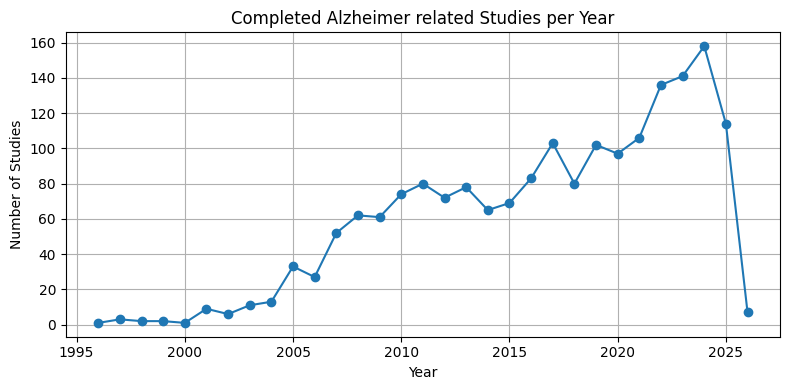

In [0]:
%python
import matplotlib.pyplot as plt
#Results converted to Pandas DataFrame for plotting
df_Plot = spark.table("df_Alztrend").toPandas()

# Line chart created to show how many Alzheimer‑related studies were completed over the years
plt.figure(figsize=(8, 4))
plt.plot(df_Plot["Year"], df_Plot["Count"], marker="o")
plt.title("Completed Alzheimer related Studies per Year")
plt.xlabel("Year")
plt.ylabel("Number of Studies")
plt.grid(True)
plt.tight_layout()
plt.show()

## Question 4
### Results
The line chart shows how many Alzheimer related studies were completed each year, after plotting the data, the increase in Alzheimer studies through the year is evident


## Conclusion Task 1: Analysis of Clinical Trial Data Using Spark SQL
As I explored the data and worked through the questions, I was able to spot patterns in the different study types, look into the different medical conditions, calculate trial lengths, and identify trends in specific areas of research. Overall, the task gave me a stronger, hands on understanding of analysing large datasets in Spark and how these techniques translate into real analytical work.